# Step 1: Load CIFAR-10, print dimensions, display samples, and plot class distribution

In [10]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Load local dataset assuming cifar-10-batches-py is in the current directory
train_set = torchvision.datasets.CIFAR10(root='.', train=True, download=True, transform=transforms.ToTensor())

# Print dataset dimensions
print("Train data shape:", train_set.data.shape)

Train data shape: (50000, 32, 32, 3)


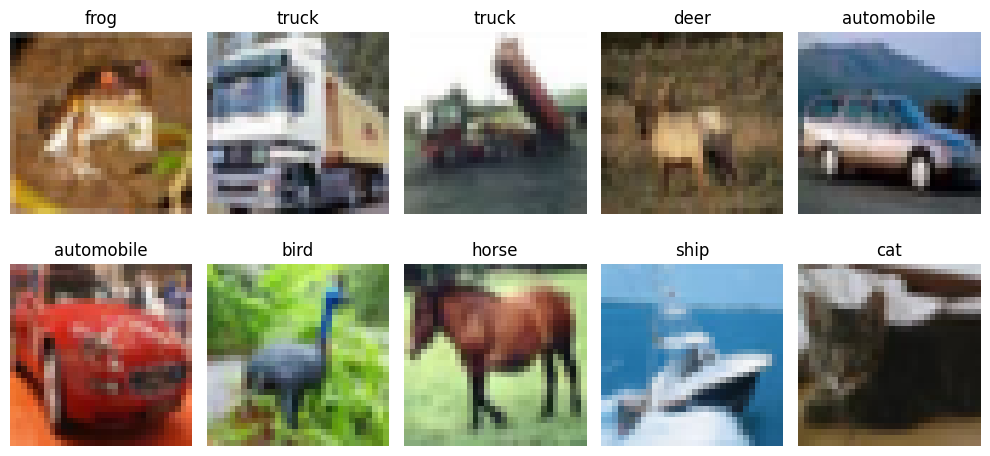

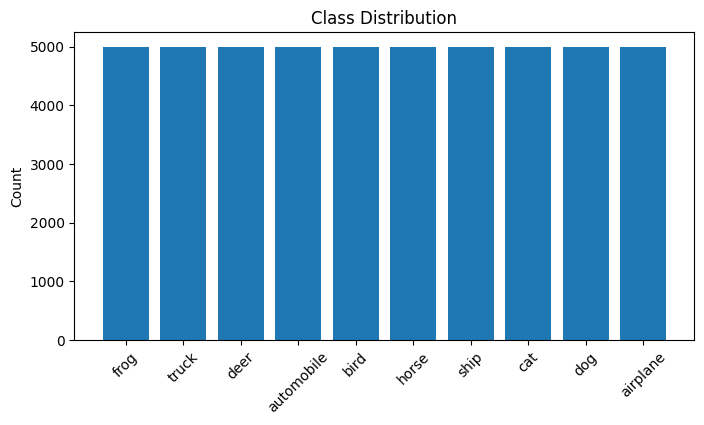

In [11]:
# Display ten sample images
classes = train_set.classes
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_set[i]
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(classes[label])
    ax.axis('off')
plt.tight_layout()
plt.show()

# Plot class distribution
counts = Counter(train_set.targets)
plt.figure(figsize=(8, 4))
plt.bar([classes[k] for k in counts.keys()], list(counts.values()))
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

# Step 2: Implement convolution layers with 3x3, 5x5, and 7x7 kernels and record feature map sizes


In [12]:
import torch
import torch.nn as nn

# Create a sample batch with CIFAR-10 dimensions (batch_size=1, channels=3, height=32, width=32)
sample_batch = torch.randn(1, 3, 32, 32)

# Define convolution layers with different kernel sizes
conv_3x3 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=0)
conv_5x5 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, stride=1, padding=0)
conv_7x7 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=7, stride=1, padding=0)

# Pass the sample batch through each layer
out_3x3 = conv_3x3(sample_batch)
out_5x5 = conv_5x5(sample_batch)
out_7x7 = conv_7x7(sample_batch)

# Display the resulting feature map dimensions
print("Input feature map size: ", sample_batch.shape)
print("Output feature map size (3x3 kernel):", out_3x3.shape)
print("Output feature map size (5x5 kernel):", out_5x5.shape)
print("Output feature map size (7x7 kernel):", out_7x7.shape)

Input feature map size:  torch.Size([1, 3, 32, 32])
Output feature map size (3x3 kernel): torch.Size([1, 16, 30, 30])
Output feature map size (5x5 kernel): torch.Size([1, 16, 28, 28])
Output feature map size (7x7 kernel): torch.Size([1, 16, 26, 26])


# Step 3: Study hyperparameter combinations for stride and padding


In [13]:
import torch
import torch.nn as nn

sample_batch = torch.randn(1, 3, 32, 32)

conv_s1_valid = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding='valid')
conv_s2_valid = nn.Conv2d(3, 16, kernel_size=3, stride=2, padding='valid')
conv_s1_same = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding='same')
conv_s2_same = nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1) # padding='same' is simulated using manual padding of 1 for stride 2

print("Stride 1, Padding Valid:", conv_s1_valid(sample_batch).shape)
print("Stride 2, Padding Valid:", conv_s2_valid(sample_batch).shape)
print("Stride 1, Padding Same:", conv_s1_same(sample_batch).shape)
print("Stride 2, Padding Same (Manual):", conv_s2_same(sample_batch).shape)

Stride 1, Padding Valid: torch.Size([1, 16, 30, 30])
Stride 2, Padding Valid: torch.Size([1, 16, 15, 15])
Stride 1, Padding Same: torch.Size([1, 16, 32, 32])
Stride 2, Padding Same (Manual): torch.Size([1, 16, 16, 16])


# Step 4: Extract and visualize eight feature maps from the first convolution layer


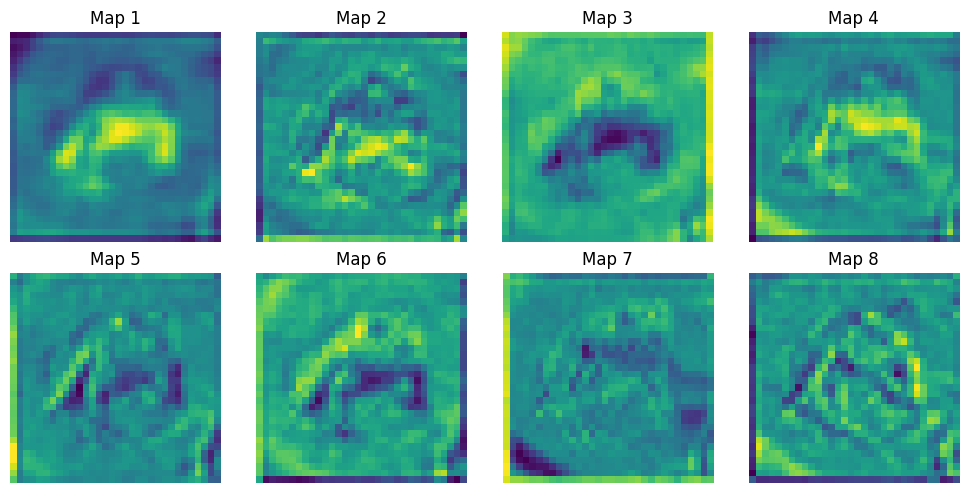

In [14]:
import matplotlib.pyplot as plt

img, _ = train_set[0]
input_tensor = img.unsqueeze(0)

conv_layer = nn.Conv2d(3, 8, kernel_size=3, stride=1, padding=1)
with torch.no_grad():
    features = conv_layer(input_tensor).squeeze(0)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(features[i].numpy(), cmap='viridis')
    ax.set_title(f"Map {i+1}")
    ax.axis('off')
plt.tight_layout()
plt.show()

# Step 5: Compare output sizes of Max Pooling and Average Pooling


In [15]:
import torch.nn as nn

# Create dummy input tensor
pool_input = torch.randn(1, 16, 32, 32)

# Initialize pooling layers
max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)

# Print output shapes
print("Input size:", pool_input.shape)
print("Max Pool output:", max_pool(pool_input).shape)
print("Average Pool output:", avg_pool(pool_input).shape)

Input size: torch.Size([1, 16, 32, 32])
Max Pool output: torch.Size([1, 16, 16, 16])
Average Pool output: torch.Size([1, 16, 16, 16])


# Step 6: Construct the CNN and train for 20 epochs


In [16]:
test_set = torchvision.datasets.CIFAR10(root='.', train=False, download=True, transform=transforms.ToTensor())

In [18]:
# Step 6: Create DataLoaders, construct CNN, initialize it, and train
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# Define DataLoaders using the datasets from Step 1
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

# Define the CNN architecture
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 10)
        )

    def forward(self, x):
        return self.model(x)

# Setup device, model, loss, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

# Initialize empty lists to store metrics per epoch
train_losses, val_losses = [], []
train_accs, val_accs = [], []

# Training loop
epochs = 20
for epoch in range(epochs):
    # Set model to training mode
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    # Iterate over training data
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Accumulate training loss and accuracy
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (preds == labels).sum().item()

    # Store average training metrics for this epoch
    train_losses.append(running_loss / len(train_loader))
    train_accs.append(correct_train / total_train)

    # Set model to evaluation mode for validation pass
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    # Disable gradient calculation for validation
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Accumulate validation loss and accuracy
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (preds == labels).sum().item()

    # Store average validation metrics for this epoch
    val_losses.append(val_loss / len(test_loader))
    val_accs.append(correct_val / total_val)

    # Print progress
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

Epoch 1/20 | Train Loss: 1.5104 | Val Loss: 1.3162
Epoch 2/20 | Train Loss: 1.2072 | Val Loss: 1.1472
Epoch 3/20 | Train Loss: 1.0768 | Val Loss: 1.0696
Epoch 4/20 | Train Loss: 0.9952 | Val Loss: 1.0121
Epoch 5/20 | Train Loss: 0.9413 | Val Loss: 1.0189
Epoch 6/20 | Train Loss: 0.9001 | Val Loss: 0.9633
Epoch 7/20 | Train Loss: 0.8668 | Val Loss: 0.9560
Epoch 8/20 | Train Loss: 0.8424 | Val Loss: 0.9944
Epoch 9/20 | Train Loss: 0.8167 | Val Loss: 0.9532
Epoch 10/20 | Train Loss: 0.7925 | Val Loss: 0.9513
Epoch 11/20 | Train Loss: 0.7754 | Val Loss: 0.9848
Epoch 12/20 | Train Loss: 0.7634 | Val Loss: 0.9315
Epoch 13/20 | Train Loss: 0.7443 | Val Loss: 0.9356
Epoch 14/20 | Train Loss: 0.7287 | Val Loss: 0.9358
Epoch 15/20 | Train Loss: 0.7160 | Val Loss: 0.9577
Epoch 16/20 | Train Loss: 0.7044 | Val Loss: 0.9419
Epoch 17/20 | Train Loss: 0.6945 | Val Loss: 0.9911
Epoch 18/20 | Train Loss: 0.6838 | Val Loss: 0.9588
Epoch 19/20 | Train Loss: 0.6753 | Val Loss: 0.9687
Epoch 20/20 | Train L

# Step 7: Evaluate the model using test data


In [19]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np

# Set model to evaluation mode
model.eval()
all_preds = []
all_labels = []

# Disable gradient calculation for inference
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Compute evaluation metrics
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='macro')
rec = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')
conf_matrix = confusion_matrix(all_labels, all_preds)
class_report = classification_report(all_labels, all_preds, target_names=train_set.classes)

# Print final metrics
print(f"Accuracy: {acc:.4f}")
print(f"Precision (Macro): {prec:.4f}")
print(f"Recall (Macro): {rec:.4f}")
print(f"F1-score (Macro): {f1:.4f}\n")
print("Confusion Matrix:\n", conf_matrix, "\n")
print("Classification Report:\n", class_report)

Accuracy: 0.6861
Precision (Macro): 0.6873
Recall (Macro): 0.6861
F1-score (Macro): 0.6848

Confusion Matrix:
 [[734  24  53  20  20   9  15  32  67  26]
 [ 21 808   7  15   5  10  11  13  30  80]
 [ 49   7 537  57  98  63  85  78  15  11]
 [ 29  13  59 521  85 136  76  56  12  13]
 [ 19   2  62  62 649  36  57  97  13   3]
 [ 13   3  50 191  48 561  35  79  12   8]
 [  7   4  41  90  49  22 765  13   5   4]
 [  9   2  38  31  40  37   8 827   1   7]
 [ 98  45  16  19  12   4   5  11 770  20]
 [ 46 129  11  32   9  14   8  33  29 689]] 

Classification Report:
               precision    recall  f1-score   support

    airplane       0.72      0.73      0.72      1000
  automobile       0.78      0.81      0.79      1000
        bird       0.61      0.54      0.57      1000
         cat       0.50      0.52      0.51      1000
        deer       0.64      0.65      0.64      1000
         dog       0.63      0.56      0.59      1000
        frog       0.72      0.77      0.74      1000

# Step 8: Generate mandatory plots (Confusion Matrix) and display inferences


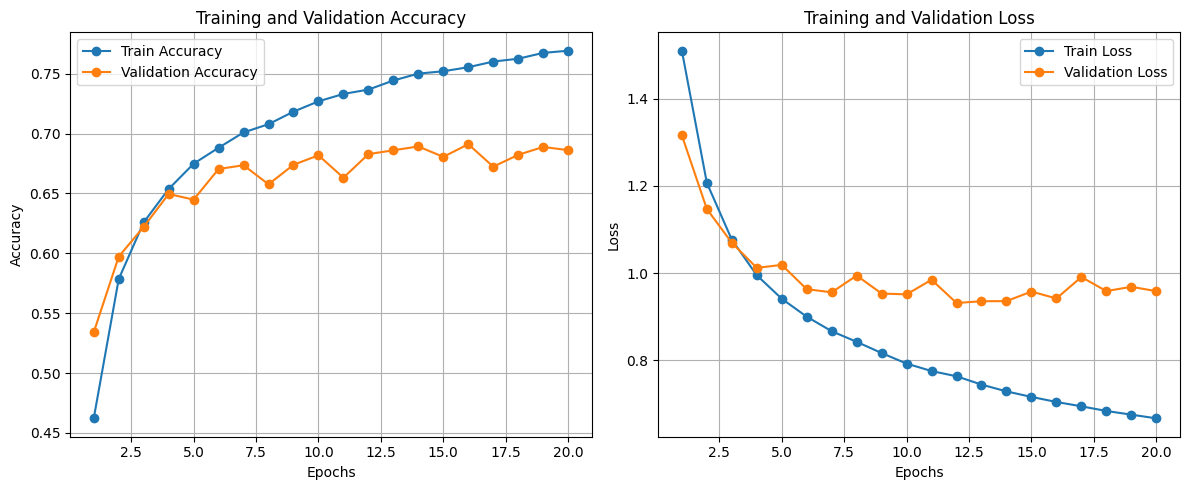

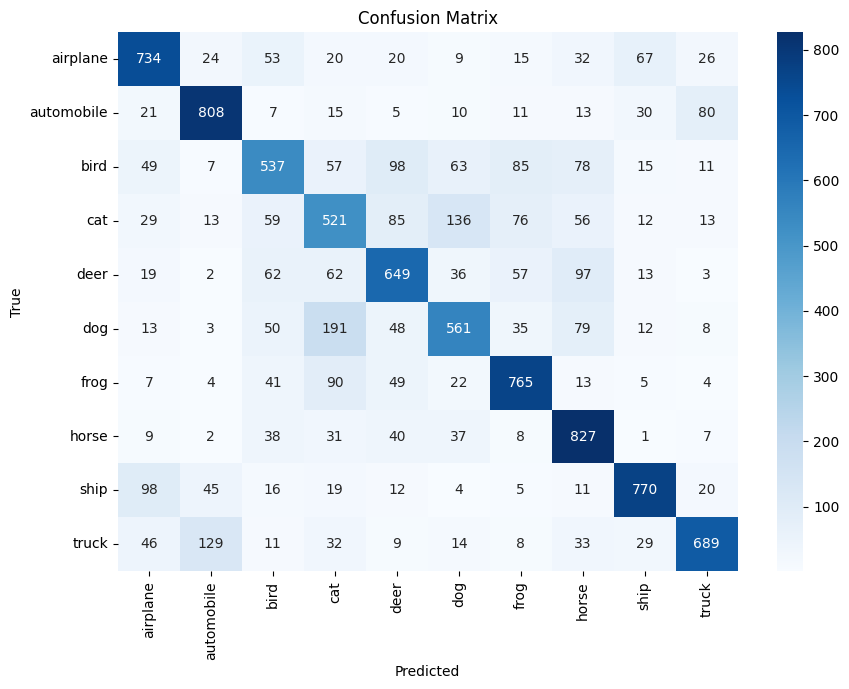

Inferences:
1. Sample Images & Class Distribution: The dataset is perfectly balanced with equal representation across all 10 classes.
2. Feature Maps: Early convolution layers effectively capture low-level features such as edges, colors, and rudimentary shapes.
3. Confusion Matrix: Misclassifications primarily occur between visually similar classes, such as cats versus dogs or trucks versus automobiles.


In [24]:
# Step 8: Plot Training and Validation Accuracy and Loss
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots side-by-side
plt.figure(figsize=(12, 5))

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_accs, label='Train Accuracy', marker='o')
plt.plot(range(1, epochs+1), val_accs, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Display the plots
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=train_set.classes, yticklabels=train_set.classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Print inferences for the required plots
print("Inferences:")
print("1. Sample Images & Class Distribution: The dataset is perfectly balanced with equal representation across all 10 classes.")
print("2. Feature Maps: Early convolution layers effectively capture low-level features such as edges, colors, and rudimentary shapes.")
print("3. Confusion Matrix: Misclassifications primarily occur between visually similar classes, such as cats versus dogs or trucks versus automobiles.")

# Step 9: Additional Exercises setup and calculations


Exercise 1 Output shape: torch.Size([1, 1, 32, 32])
Exercise 2 Trainable parameters: 1792


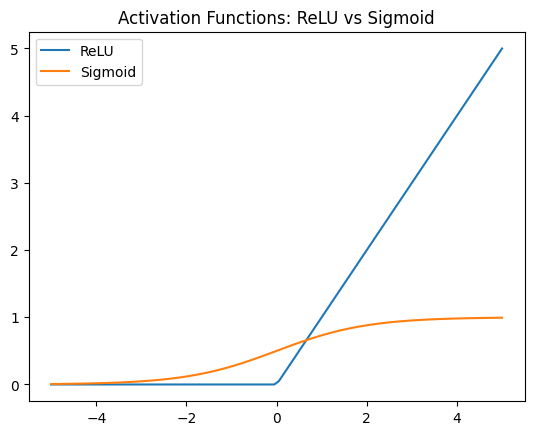

In [21]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. Calculate output size for 64x64 image using 5x5 kernel, stride 2, padding 2
conv_ex1 = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=5, stride=2, padding=2)
print("Exercise 1 Output shape:", conv_ex1(torch.randn(1, 3, 64, 64)).shape)

# 2. Compute trainable parameters for 64 filters of size 3x3 on RGB input
conv_ex2 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3)
print("Exercise 2 Trainable parameters:", sum(p.numel() for p in conv_ex2.parameters()))

# 3. Compare ReLU and Sigmoid activation functions visually
x = torch.linspace(-5, 5, 100)
plt.plot(x.numpy(), torch.relu(x).numpy(), label='ReLU')
plt.plot(x.numpy(), torch.sigmoid(x).numpy(), label='Sigmoid')
plt.legend()
plt.title("Activation Functions: ReLU vs Sigmoid")
plt.show()

# 4. CNN Architecture replacing Max Pooling with Average Pooling
class AvgPoolCNN(nn.Module):
    def __init__(self):
        super(AvgPoolCNN, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.AvgPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.AvgPool2d(2, 2),
            nn.Flatten(), nn.Linear(32 * 8 * 8, 10)
        )

# 5. CNN Architecture increasing convolution filters from 16 to 64
class IncreasedFiltersCNN(nn.Module):
    def __init__(self):
        super(IncreasedFiltersCNN, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Flatten(), nn.Linear(128 * 8 * 8, 10)
        )

In [22]:
print("--- Final Results ---")
print(f"Testing Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Number of Parameters: {sum(p.numel() for p in model.parameters())}")

--- Final Results ---
Testing Accuracy: 0.6861
Precision: 0.6873
Recall: 0.6861
F1-score: 0.6848
Number of Parameters: 25578
